In [65]:
import pandas as pd
import numpy as np
from Bio import SeqIO
from Bio.Data import CodonTable
import os
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

def read_gene_expression(file_path):
    """
    Read gene expression data with RNA-Seq RSEM normalized values

    Parameters:
    file_path (str): Path to gene expression file

    Returns:
    pandas.DataFrame: DataFrame with patient_id, sample_id and gene expression values
    """
    # Read the tab-separated file
    df = pd.read_csv(file_path, sep='\t')
    print(f"Gene expression data loaded: {df.shape[0]} samples, {df.shape[1]-2} genes")
    return df

def read_somatic_mutations(file_path):
    """
    Read somatic mutations data in MAF format

    Parameters:
    file_path (str): Path to mutation annotation file
    2`x
    Returns:
    pandas.DataFrame: DataFrame with mutation information
    """
    # Read the tab-separated MAF file
    df = pd.read_csv(file_path, sep='\t')
    print(f"Somatic mutations data loaded: {df.shape[0]} mutations")
    return df

def read_patient_metadata(file_path):
    """
    Read patient clinical and pathological metadata

    Parameters:
    file_path (str): Path to patient metadata file

    Returns:
    pandas.DataFrame: DataFrame with patient clinical information
    """
    # Read the tab-separated metadata file
    df = pd.read_csv(file_path, sep='\t')
    print(f"Patient metadata loaded: {df.shape[0]} patients")
    return df

def explore_data(gene_expr, somatic_mut, patient_meta):
    """
    Basic exploration of the three datasets
    """
    # Explore patient metadata
    print("\nPatient demographics:")
    print(f"Gender distribution:\n{patient_meta['gender'].value_counts()}")
    print(f"Age statistics:\n{patient_meta['age_at_initial_pathologic_diagnosis'].describe()}")

    # Analyze survival data
    print("\nSurvival statistics:")
    print(f"Overall survival events: {patient_meta['DSS'].sum()} deaths out of {patient_meta['DSS'].count()} patients")

    # Look at mutations per patient
    if 'patient_id' in somatic_mut.columns:
        mutations_per_patient = somatic_mut['patient_id'].value_counts()
        print(f"\nMutations per patient statistics:")
        print(mutations_per_patient.describe())

    # For gene expression, we could look at the most variable genes
    if gene_expr is not None and gene_expr.shape[1] > 2:
        print("\nGene expression statistics:")
        gene_columns = gene_expr.columns[2:]  # Skipping patient_id and sample_id
        gene_variance = gene_expr[gene_columns].var().sort_values(ascending=False)
        print(f"Top 5 most variable genes:\n{gene_variance.head(5)}")

gene_expression_path = os.path.join(os.getcwd(), 'Team_4_STAD', 'TCGA.STAD.expression.txt')
somatic_mutations_path = os.path.join(os.getcwd(), 'Team_4_STAD', 'TCGA.STAD.mutations.txt')
metadata_path = os.path.join(os.getcwd(),'Team_4_STAD', 'TCGA.STAD.metadata.txt')

gene_expr = read_gene_expression(gene_expression_path)
somatic_mut = read_somatic_mutations(somatic_mutations_path)
patient_meta = read_patient_metadata(metadata_path)

Gene expression data loaded: 447 samples, 20531 genes
Somatic mutations data loaded: 234941 mutations
Patient metadata loaded: 415 patients


In [66]:
### ----------------------------------------------------
### 1.  Construct 5-year DSS label
### ----------------------------------------------------
# English comments inside code
# We assume patient_meta has: 'DSS' (1=death,0=alive) and 'DSS_time' (months)

# Create 5-year (60-month) binary outcome
patient_meta['label_5yr'] = (
    (patient_meta['DSS'] == 1) & (patient_meta['DSS.time'] <= 240)
).astype(int)

print("Positive cases (death within 5y):", patient_meta['label_5yr'].sum())
print("Negative cases:", (patient_meta['label_5yr'] == 0).sum())

Positive cases (death within 5y): 20
Negative cases: 395


In [67]:
### ----------------------------------------------------
### 2.  Merge gene expression with clinical labels
### ----------------------------------------------------
# Keep only expression columns and patient_id
from sklearn.preprocessing import FunctionTransformer

expr_only = gene_expr.drop(columns=['sample_id'], errors='ignore')
data = expr_only.merge(
    patient_meta[['patient_id', 'label_5yr']], on='patient_id', how='inner'
)

# Separate features and labels
X = data.drop(columns=['patient_id', 'label_5yr'])
y = data['label_5yr']

# Basic preprocessing: log2(x+1) transform, median imputation, z-score scaling
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

preprocess = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('log',      FunctionTransformer(lambda x: np.log2(x + 1), validate=False)),
    ('scale',   StandardScaler())
])

X_processed = preprocess.fit_transform(X)


In [68]:
### ----------------------------------------------------
### 3.  Train-test split (stratified 80/20)
### ----------------------------------------------------
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, stratify=y, random_state=42
)
print("Train set size:", X_train.shape, " Test set size:", X_test.shape)


Train set size: (357, 20531)  Test set size: (90, 20531)


In [69]:
### --- Revised feature-selection pipeline ---
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.linear_model import LogisticRegression

var_filter = VarianceThreshold(threshold=1e-4)
X_var = var_filter.fit_transform(X_train)

log_reg = LogisticRegression(
    penalty='l1', C=2.0, solver='liblinear', class_weight='balanced',
    max_iter=500
)
sfm = SelectFromModel(log_reg, threshold='mean', max_features=150)
sfm.fit(X_var, y_train)

X_train_sel = sfm.transform(X_var)
X_test_sel  = sfm.transform(var_filter.transform(X_test))

print("Selected features:", X_train_sel.shape[1])

Selected features: 144


In [70]:
### ----------------------------------------------------
### 5.  Model training: RandomForest + GridSearchCV
### ----------------------------------------------------
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
print("Train label counts:\n", y_train.value_counts())
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    rf, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1
)
grid.fit(X_train_sel, y_train)

print("Best params:", grid.best_params_)
print("Best CV AUC:", grid.best_score_)
best_model = grid.best_estimator_

Train label counts:
 label_5yr
0    341
1     16
Name: count, dtype: int64
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 400}
Best CV AUC: 0.9206912475134981


In [71]:
### ----------------------------------------------------
### 5-B.  Gaussian Naive Bayes (baseline)
### ----------------------------------------------------
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedShuffleSplit, cross_val_score

nb_clf = GaussianNB()

# Use the same selected features
cv_sss = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

nb_auc = cross_val_score(
    nb_clf, X_train_sel, y_train,
    cv=cv_sss, scoring='roc_auc'
)

print("GaussianNB CV AUCs:", nb_auc)
print("GaussianNB mean CV AUC:", nb_auc.mean())


GaussianNB CV AUCs: [1.         1.         0.99516908 1.         0.71497585]
GaussianNB mean CV AUC: 0.9420289855072463


In [72]:
### ----------------------------------------------------
### 5-C.  Support Vector Machine + GridSearchCV
### ----------------------------------------------------
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Pipeline: scaling  ->  SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),  # sparse-safe
    ('svm', SVC(kernel='rbf', probability=True, class_weight='balanced'))
])

svm_param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 0.01, 0.001]
}

cv_sss = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

svm_grid = GridSearchCV(
    svm_pipe, svm_param_grid,
    cv=cv_sss, scoring='roc_auc',
    n_jobs=-1, verbose=1, error_score='raise'
)
svm_grid.fit(X_train_sel, y_train)

print("SVM best params:", svm_grid.best_params_)
print("SVM best CV AUC:", svm_grid.best_score_)
best_svm = svm_grid.best_estimator_


Fitting 5 folds for each of 9 candidates, totalling 45 fits
SVM best params: {'svm__C': 1, 'svm__gamma': 'scale'}
SVM best CV AUC: 1.0


In [77]:
### ----------------------------------------------------
### 5-D.  XGBoost + GridSearchCV  (handles imbalance via scale_pos_weight)
### ----------------------------------------------------
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
import numpy as np

# Compute imbalance ratio for scale_pos_weight
neg, pos = np.bincount(y_train)
scale_pos = neg / max(pos, 1)   # avoid div-zero

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    use_label_encoder=False,
    n_jobs=-1,
    random_state=42,
    scale_pos_weight=scale_pos,   # key for imbalance
    tree_method='hist'            # faster on CPU
)

xgb_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [3, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

cv_sss = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

xgb_grid = GridSearchCV(
    xgb, xgb_param_grid,
    cv=cv_sss, scoring='roc_auc',
    n_jobs=-1, verbose=1, error_score='raise'
)
xgb_grid.fit(X_train_sel, y_train)

print("XGBoost best params:", xgb_grid.best_params_)
print("XGBoost best CV AUC:", xgb_grid.best_score_)
best_xgb = xgb_grid.best_estimator_

Fitting 5 folds for each of 32 candidates, totalling 160 fits


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [10:52:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [10:52:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [10:52:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [10:52:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

XGBoost best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
XGBoost best CV AUC: 0.8898550724637682


In [79]:
### ----------------------------------------------------
### Compare four models on the held-out test set
### ----------------------------------------------------
import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score
)

def eval_model(model, X, y, name, thr=0.5):
    """
    Evaluate a fitted classifier on X, y and return a pandas Series.
    If model lacks predict_proba, fall back to decision_function.
    """
    # --- probability / score ---
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X)[:, 1]
    else:
        df = model.decision_function(X)
        y_score = df if df.ndim == 1 else df[:, 1]

    # --- binary prediction at threshold ---
    y_pred = (y_score >= thr).astype(int)

    # --- metrics ---
    metrics = {
        "AUC": roc_auc_score(y, y_score) if len(np.unique(y)) > 1 else np.nan,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred, zero_division=0),
        "Recall": recall_score(y, y_pred, zero_division=0),
        "Specificity": recall_score(y, y_pred, pos_label=0, zero_division=0),
        "F1": f1_score(y, y_pred, zero_division=0)
    }
    return pd.Series(metrics, name=name)

# ------------------------------------------------------
# Ensure GaussianNB is fitted (others已在 GridSearch 中fit过)
if not hasattr(nb_clf, "class_prior_"):
    nb_clf.fit(X_train_sel, y_train)

models = {
    "RandomForest": best_model,
    "GaussianNB":  nb_clf,
    "SVM":         best_svm,
    "XGBoost":     best_xgb
}

results = pd.DataFrame(
    [eval_model(m, X_test_sel, y_test, n) for n, m in models.items()]
).sort_values("AUC", ascending=False).round(3)

print(results)


                AUC  Accuracy  Precision  Recall  Specificity   F1
SVM           0.570     0.933        0.0     0.0        0.977  0.0
XGBoost       0.555     0.956        0.0     0.0        1.000  0.0
RandomForest  0.542     0.956        0.0     0.0        1.000  0.0
GaussianNB    0.343     0.856        0.0     0.0        0.895  0.0


AUC                     0.542
Accuracy                0.956
Precision               0.000
Recall (Sensitivity)    0.000
Specificity             1.000
F1                      0.000
dtype: float64


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


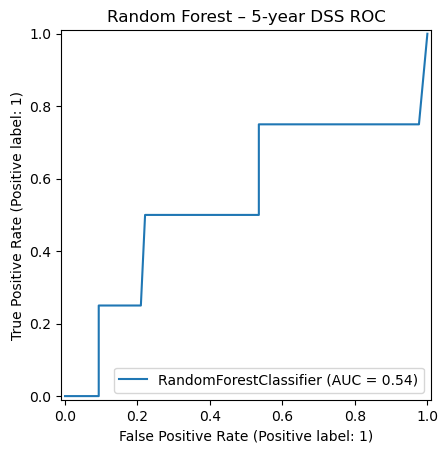

In [80]:
### ----------------------------------------------------
### 6.  Test-set evaluation
### ----------------------------------------------------
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, RocCurveDisplay
)
y_pred = best_model.predict(X_test_sel)
y_prob = best_model.predict_proba(X_test_sel)[:, 1]

metrics = {
    'AUC': roc_auc_score(y_test, y_prob),
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall (Sensitivity)': recall_score(y_test, y_pred),
    'Specificity': recall_score(y_test, y_pred, pos_label=0),
    'F1': f1_score(y_test, y_pred)
}
print(pd.Series(metrics).round(3))

# Plot ROC curve
import matplotlib.pyplot as plt
RocCurveDisplay.from_estimator(best_model, X_test_sel, y_test)
plt.title('Random Forest – 5-year DSS ROC')
plt.show()


In [ ]:
# ============================================================
# Compare four classifiers on the held-out test set
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, RocCurveDisplay
)

# ------------------------------------------------------------
# 1.  Make sure GaussianNB is fitted
# ------------------------------------------------------------
if not hasattr(nb_clf, "class_prior_"):
    nb_clf.fit(X_train_sel, y_train)

models = {
    "RandomForest": best_model,
    "GaussianNB":  nb_clf,
    "SVM":         best_svm,
    "XGBoost":     best_xgb
}

# ------------------------------------------------------------
# 2.  Helper to compute metrics & return Series
# ------------------------------------------------------------
def eval_model(model, X, y, name, thr=0.5):
    # Get continuous score
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X)[:, 1]
    else:                                   # e.g. linear-SVM
        df = model.decision_function(X)
        y_score = df if df.ndim == 1 else df[:, 1]

    # Binarize at threshold
    y_pred = (y_score >= thr).astype(int)

    # Metrics
    metrics = {
        "AUC": roc_auc_score(y, y_score) if len(np.unique(y)) > 1 else np.nan,
        "Accuracy":  accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred, zero_division=0),
        "Recall":    recall_score(y, y_pred, zero_division=0),
        "Specificity": recall_score(y, y_pred, pos_label=0, zero_division=0),
        "F1":        f1_score(y, y_pred, zero_division=0)
    }
    return pd.Series(metrics, name=name), y_score

# ------------------------------------------------------------
# 3.  Evaluate all models & collect results
# ------------------------------------------------------------
metric_list, score_dict = [], {}
for name, clf in models.items():
    m, s = eval_model(clf, X_test_sel, y_test, name)
    metric_list.append(m)
    score_dict[name] = s

results = pd.DataFrame(metric_list).round(3).sort_values("AUC", ascending=False)
print("=== Test-set metrics (5-year DSS) ===")
display(results)          # Jupyter 富输出；若用纯脚本可改 print(results)

# ------------------------------------------------------------
# 4.  Plot ROC curves in a single figure
# ------------------------------------------------------------
plt.figure(figsize=(6, 6))
ax = plt.gca()
for name, clf in models.items():
    try:
        RocCurveDisplay.from_estimator(clf, X_test_sel, y_test,
                                       ax=ax, name=name)
    except ValueError:
        # If y_test has only one class, ROC is not defined
        print(f"Skipped ROC for {name}: y_test single-class.")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey")
plt.title("ROC Curves – 5-year DSS (Test Set)")
plt.tight_layout()
plt.show()


               Gene  Importance
18   C2orf27A|29798    0.039066
35     CRYGN|155051    0.030563
1           ACO1|48    0.028940
91      PHF5A|84844    0.024503
137      UPK1B|7348    0.020351
5         ALOX5|240    0.016584
54    H2AFB1|474382    0.016526
104  SERINC4|619189    0.015477
97        RAG1|5896    0.014457
37    CT45A5|441521    0.014272
126    SYNGR4|23546    0.013552
102    SEC61G|23480    0.013309
67   KIAA1239|57495    0.012736
62      IL31|386653    0.012688
131   TMEM81|388730    0.012523
135    UBQLN1|29979    0.011956
143  ZSCAN5B|342933    0.011841
64        IRS2|8660    0.011774
53       GPR50|9248    0.011696
117   SPRED3|399473    0.011546
